Kent Lin Chan

20202132

Se usó python 3.14.2

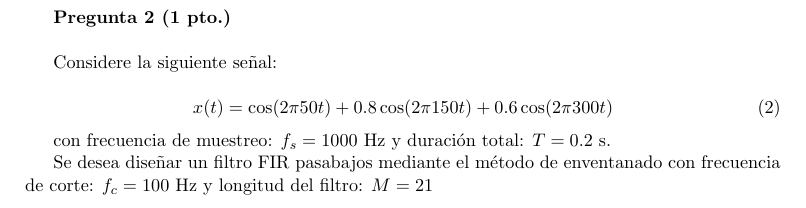

In [16]:
import numpy as np
import matplotlib.pyplot as plt

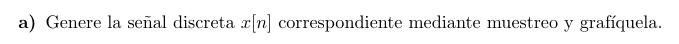

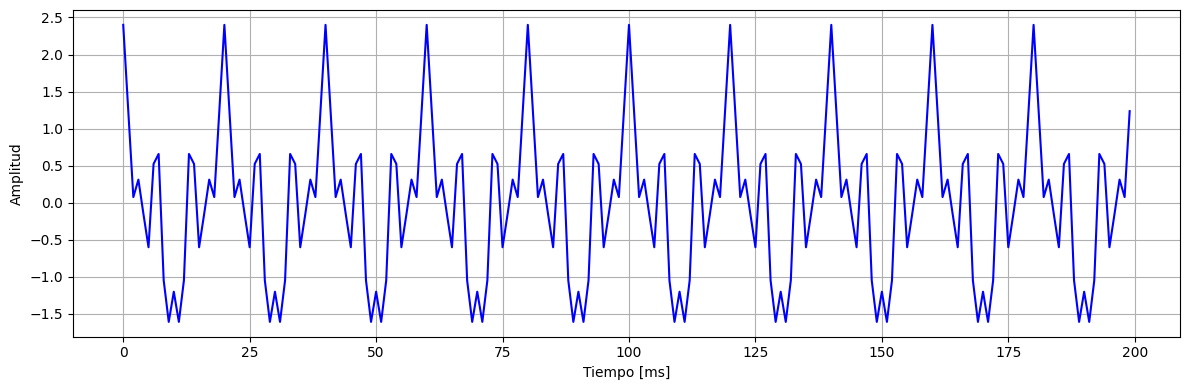

In [17]:
fs = 1000
T = 0.2
N = int(fs * T)

n = np.arange(N)
t = n / fs

x = np.cos(2*np.pi*50*t) + 0.8*np.cos(2*np.pi*150*t) + 0.6*np.cos(2*np.pi*300*t)

plt.figure(figsize=[12, 4])
plt.plot(t*1000, x, 'b-')
plt.xlabel('Tiempo [ms]')
plt.ylabel('Amplitud')
plt.grid('on')


plt.tight_layout()
plt.show()

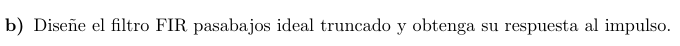

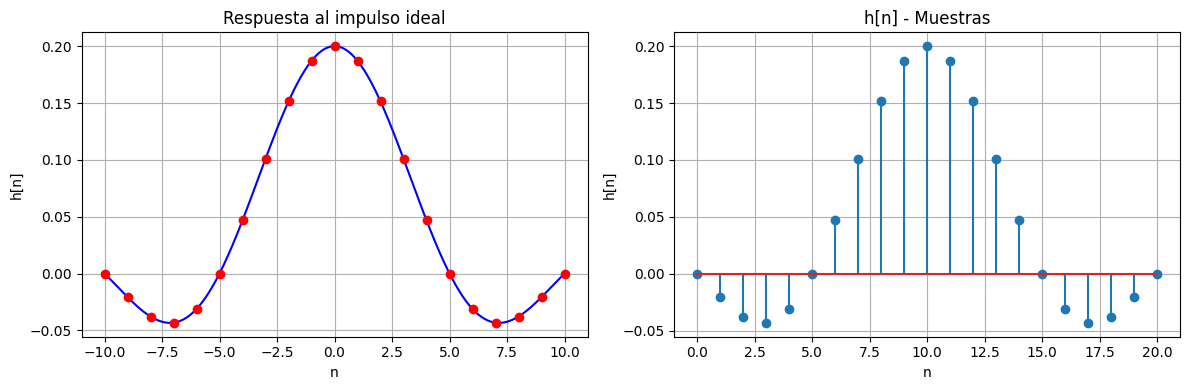

In [18]:
fc = 100
wc = 2*np.pi*fc/fs
M = 21
nd = (M-1)//2

n_h = np.arange(-nd, nd+1)
hn_ideal = (wc/np.pi) * np.sinc(wc/np.pi * n_h)

x_cont = np.linspace(-nd, nd, 1001)
h_cont = (wc/np.pi) * np.sinc(wc/np.pi * x_cont)

plt.figure(figsize=[12, 4])
plt.subplot(1, 2, 1)
plt.plot(x_cont, h_cont, 'b-')
plt.plot(n_h, hn_ideal, 'ro')
plt.xlabel('n')
plt.ylabel('h[n]')
plt.title('Respuesta al impulso ideal')
plt.grid('on')

plt.subplot(1, 2, 2)
plt.stem(hn_ideal)
plt.xlabel('n')
plt.ylabel('h[n]')
plt.title('h[n] - Muestras')
plt.grid('on')

plt.tight_layout()
plt.show()

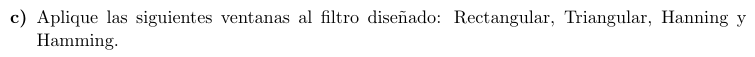

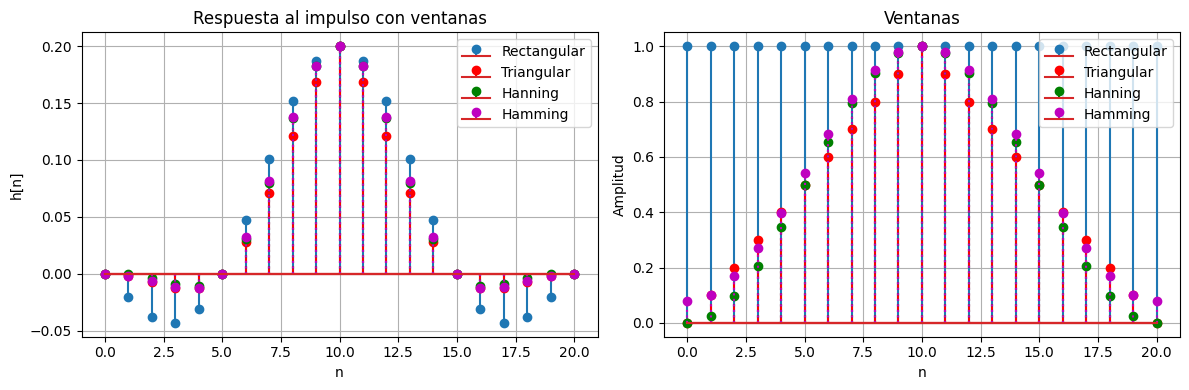

In [19]:
ventana_rectangular = np.ones(M)
ventana_triangular = np.bartlett(M)
ventana_hanning = np.hanning(M)
ventana_hamming = np.hamming(M)

hn_rect = hn_ideal * ventana_rectangular
hn_tri = hn_ideal * ventana_triangular
hn_hann = hn_ideal * ventana_hanning
hn_ham = hn_ideal * ventana_hamming

fig = plt.figure(figsize=[12, 4])
plt.subplot(1, 2, 1)
plt.stem(hn_rect, label='Rectangular')
plt.stem(hn_tri, linefmt='r--', markerfmt='ro', label='Triangular')
plt.stem(hn_hann, linefmt='g:', markerfmt='go', label='Hanning')
plt.stem(hn_ham, linefmt='m:', markerfmt='mo', label='Hamming')
plt.xlabel('n')
plt.ylabel('h[n]')
plt.title('Respuesta al impulso con ventanas')
plt.grid('on')
plt.legend()

plt.subplot(1, 2, 2)
plt.stem(ventana_rectangular, label='Rectangular')
plt.stem(ventana_triangular, linefmt='r--', markerfmt='ro', label='Triangular')
plt.stem(ventana_hanning, linefmt='g:', markerfmt='go', label='Hanning')
plt.stem(ventana_hamming, linefmt='m:', markerfmt='mo', label='Hamming')
plt.xlabel('n')
plt.ylabel('Amplitud')
plt.title('Ventanas')
plt.grid('on')
plt.legend(loc='upper right')

plt.tight_layout()
plt.show()

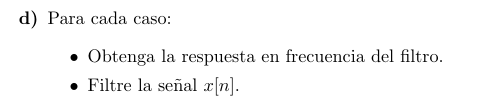

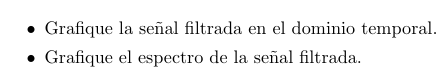

Ventana Rectangular

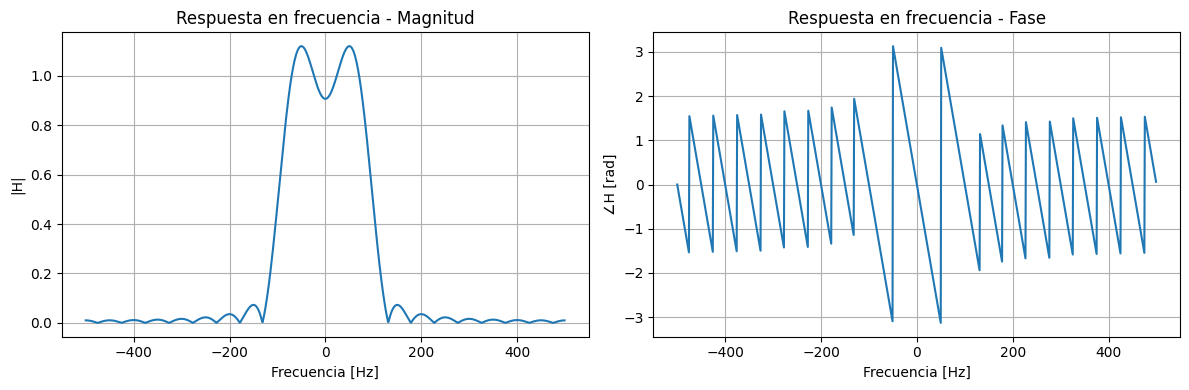

In [20]:
Nfft = 1024
Hw_rect = np.fft.fft(hn_rect, Nfft)
Hw_rect = np.fft.fftshift(Hw_rect)
w = 2*np.pi*(np.arange(Nfft) - Nfft/2)/Nfft

fig = plt.figure(figsize=[12, 4])
plt.subplot(1, 2, 1)
plt.plot(w*fs/(2*np.pi), np.abs(Hw_rect))
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('|H|')
plt.title('Respuesta en frecuencia - Magnitud')
plt.grid('on')

plt.subplot(1, 2, 2)
plt.plot(w*fs/(2*np.pi), np.angle(Hw_rect))
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('∠H [rad]')
plt.title('Respuesta en frecuencia - Fase')
plt.grid('on')

plt.tight_layout()
plt.show()

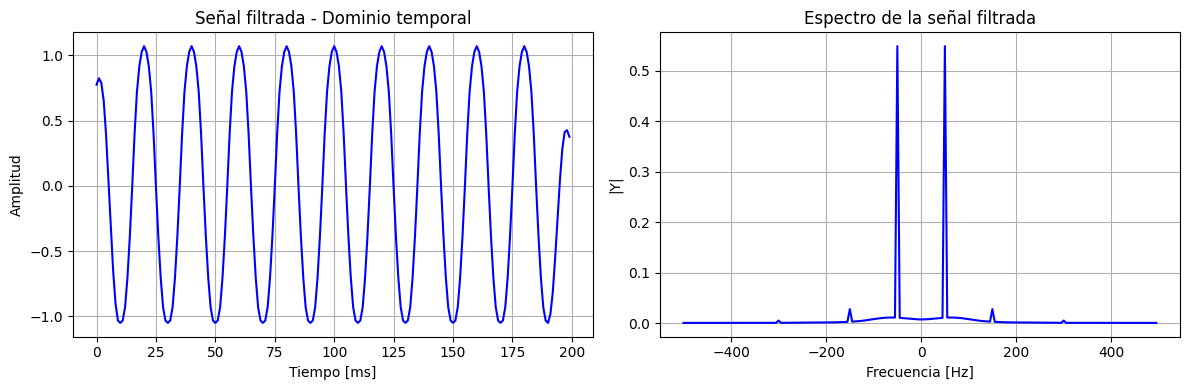

In [21]:
y_rect = np.convolve(x, hn_rect, mode='same')

plt.figure(figsize=[12, 4])
plt.subplot(1, 2, 1)
plt.plot(t*1000, y_rect, 'b-')
plt.xlabel('Tiempo [ms]')
plt.ylabel('Amplitud')
plt.title('Señal filtrada - Dominio temporal')
plt.grid('on')

Y_rect = np.fft.fft(y_rect)
Y_rect = np.fft.fftshift(Y_rect)
f = (np.arange(N) - N/2) * fs/N

plt.subplot(1, 2, 2)
plt.plot(f, np.abs(Y_rect)/N, 'b-')
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('|Y|')
plt.title('Espectro de la señal filtrada')
plt.grid('on')

plt.tight_layout()
plt.show()

Ventana triangular

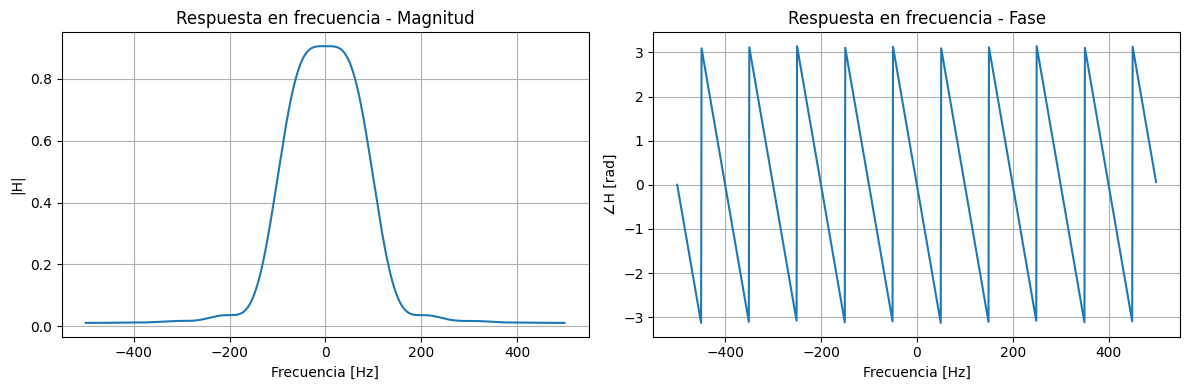

In [22]:
Hw_tri = np.fft.fft(hn_tri, Nfft)
Hw_tri = np.fft.fftshift(Hw_tri)

fig = plt.figure(figsize=[12, 4])
plt.subplot(1, 2, 1)
plt.plot(w*fs/(2*np.pi), np.abs(Hw_tri))
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('|H|')
plt.title('Respuesta en frecuencia - Magnitud')
plt.grid('on')

plt.subplot(1, 2, 2)
plt.plot(w*fs/(2*np.pi), np.angle(Hw_tri))
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('∠H [rad]')
plt.title('Respuesta en frecuencia - Fase')
plt.grid('on')

plt.tight_layout()
plt.show()

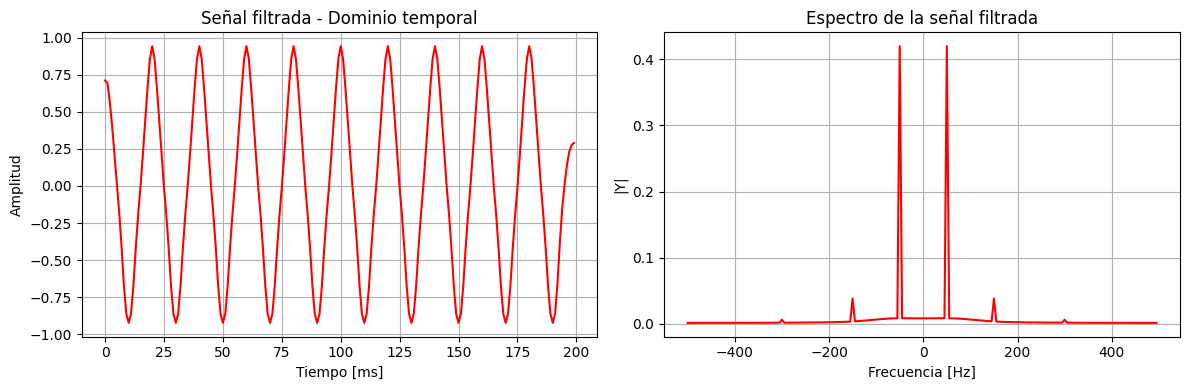

In [23]:
y_tri = np.convolve(x, hn_tri, mode='same')

plt.figure(figsize=[12, 4])
plt.subplot(1, 2, 1)
plt.plot(t*1000, y_tri, 'r-')
plt.xlabel('Tiempo [ms]')
plt.ylabel('Amplitud')
plt.title('Señal filtrada - Dominio temporal')
plt.grid('on')

Y_tri = np.fft.fft(y_tri)
Y_tri = np.fft.fftshift(Y_tri)

plt.subplot(1, 2, 2)
plt.plot(f, np.abs(Y_tri)/N, 'r-')
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('|Y|')
plt.title('Espectro de la señal filtrada')
plt.grid('on')

plt.tight_layout()
plt.show()

Ventana Hanning

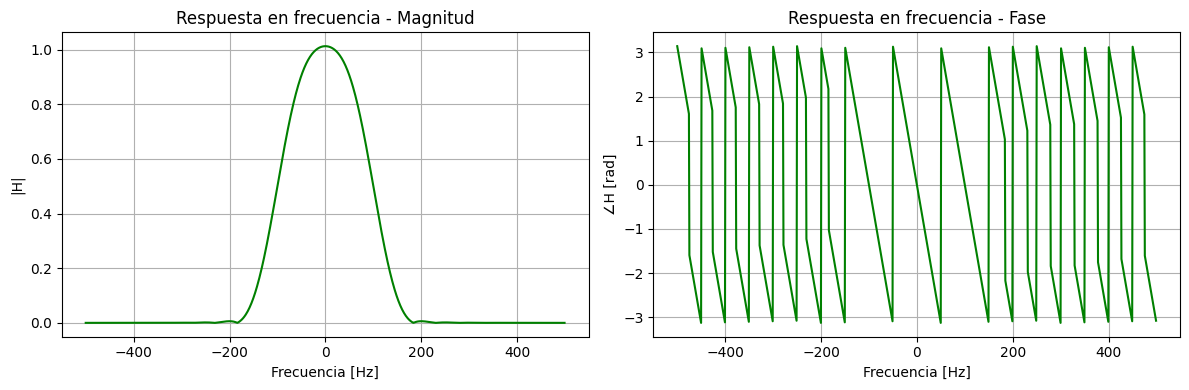

In [24]:
Hw_hann = np.fft.fft(hn_hann, Nfft)
Hw_hann = np.fft.fftshift(Hw_hann)

fig = plt.figure(figsize=[12, 4])
plt.subplot(1, 2, 1)
plt.plot(w*fs/(2*np.pi), np.abs(Hw_hann), 'g-')
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('|H|')
plt.title('Respuesta en frecuencia - Magnitud')
plt.grid('on')

plt.subplot(1, 2, 2)
plt.plot(w*fs/(2*np.pi), np.angle(Hw_hann), 'g-')
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('∠H [rad]')
plt.title('Respuesta en frecuencia - Fase')
plt.grid('on')

plt.tight_layout()
plt.show()

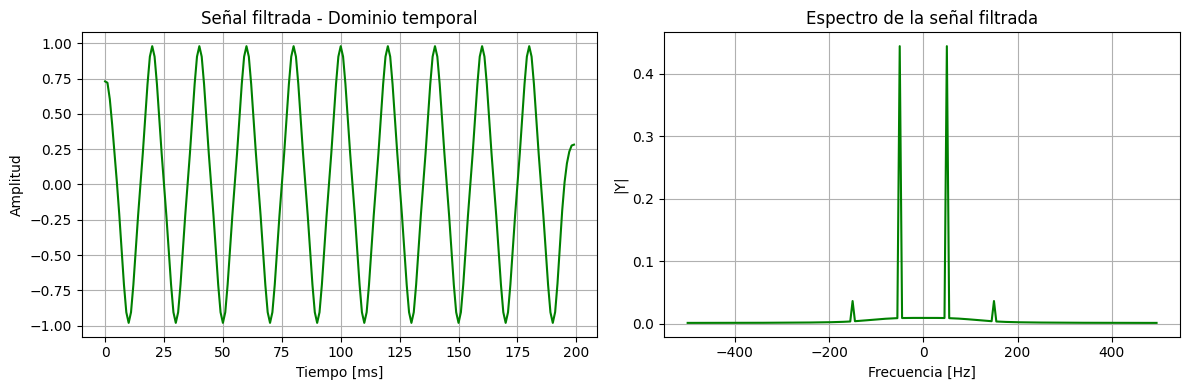

In [25]:
y_hann = np.convolve(x, hn_hann, mode='same')

plt.figure(figsize=[12, 4])
plt.subplot(1, 2, 1)
plt.plot(t*1000, y_hann, 'g-')
plt.xlabel('Tiempo [ms]')
plt.ylabel('Amplitud')
plt.title('Señal filtrada - Dominio temporal')
plt.grid('on')

Y_hann = np.fft.fft(y_hann)
Y_hann = np.fft.fftshift(Y_hann)

plt.subplot(1, 2, 2)
plt.plot(f, np.abs(Y_hann)/N, 'g-')
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('|Y|')
plt.title('Espectro de la señal filtrada')
plt.grid('on')

plt.tight_layout()
plt.show()

Ventana Hamming

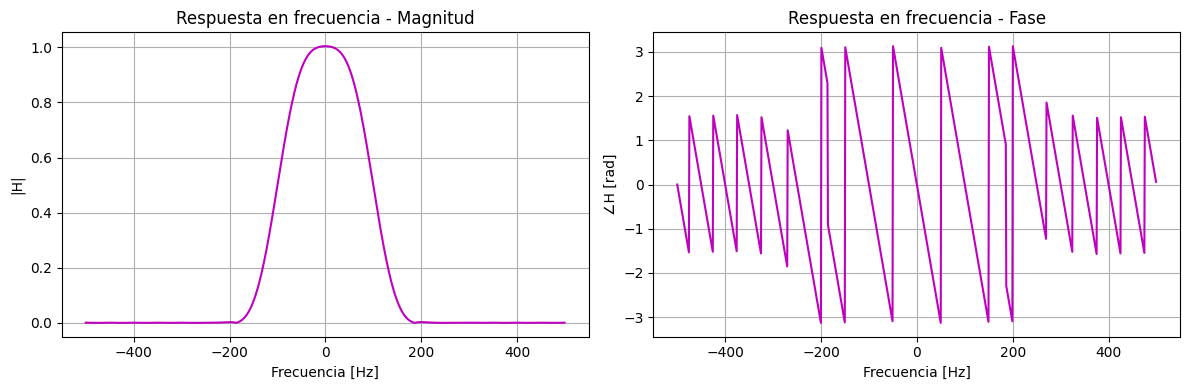

In [26]:
Hw_ham = np.fft.fft(hn_ham, Nfft)
Hw_ham = np.fft.fftshift(Hw_ham)

fig = plt.figure(figsize=[12, 4])
plt.subplot(1, 2, 1)
plt.plot(w*fs/(2*np.pi), np.abs(Hw_ham), 'm-')
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('|H|')
plt.title('Respuesta en frecuencia - Magnitud')
plt.grid('on')

plt.subplot(1, 2, 2)
plt.plot(w*fs/(2*np.pi), np.angle(Hw_ham), 'm-')
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('∠H [rad]')
plt.title('Respuesta en frecuencia - Fase')
plt.grid('on')

plt.tight_layout()
plt.show()

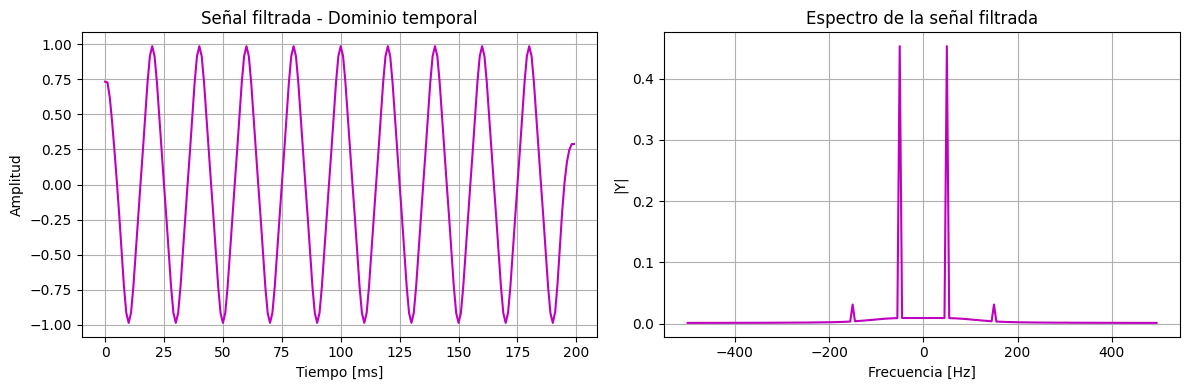

In [27]:
y_ham = np.convolve(x, hn_ham, mode='same')

plt.figure(figsize=[12, 4])
plt.subplot(1, 2, 1)
plt.plot(t*1000, y_ham, 'm-')
plt.xlabel('Tiempo [ms]')
plt.ylabel('Amplitud')
plt.title('Señal filtrada - Dominio temporal')
plt.grid('on')

Y_ham = np.fft.fft(y_ham)
Y_ham = np.fft.fftshift(Y_ham)

plt.subplot(1, 2, 2)
plt.plot(f, np.abs(Y_ham)/N, 'm-')
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('|Y|')
plt.title('Espectro de la señal filtrada')
plt.grid('on')

plt.tight_layout()
plt.show()

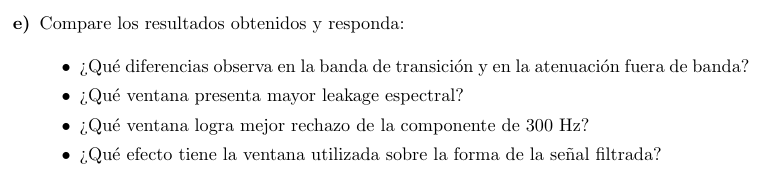

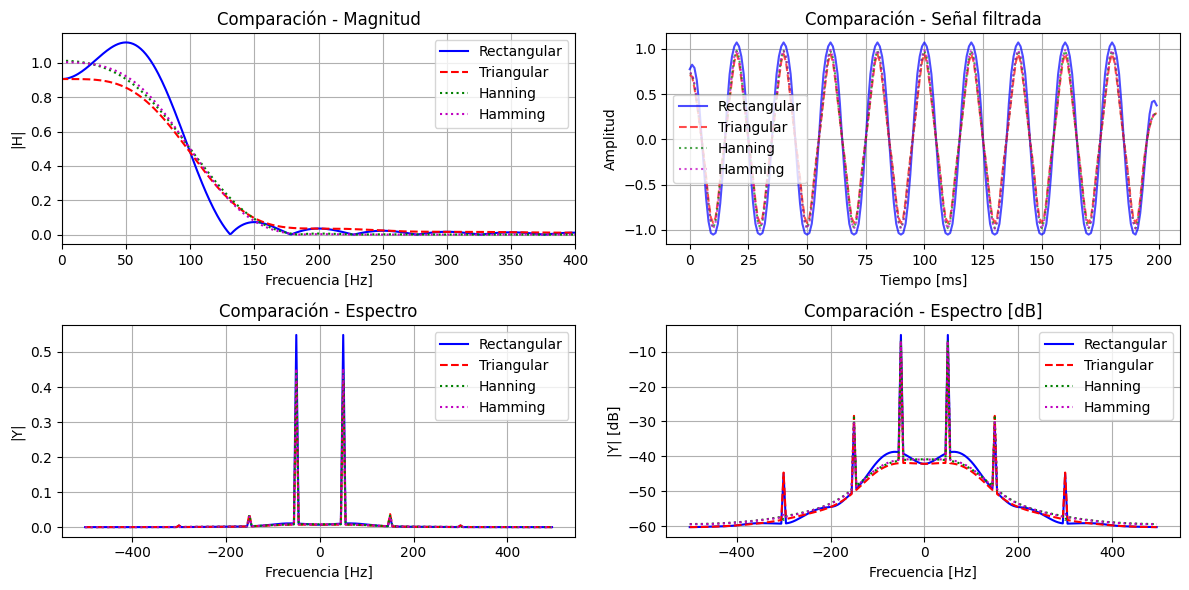

In [28]:
fig = plt.figure(figsize=[12, 6])
plt.subplot(2, 2, 1)
plt.plot(w*fs/(2*np.pi), np.abs(Hw_rect), 'b-', label='Rectangular')
plt.plot(w*fs/(2*np.pi), np.abs(Hw_tri), 'r--', label='Triangular')
plt.plot(w*fs/(2*np.pi), np.abs(Hw_hann), 'g:', label='Hanning')
plt.plot(w*fs/(2*np.pi), np.abs(Hw_ham), 'm:', label='Hamming')
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('|H|')
plt.title('Comparación - Magnitud')
plt.legend()
plt.grid('on')
plt.xlim(0, 400)

plt.subplot(2, 2, 2)
plt.plot(t*1000, y_rect, 'b-', label='Rectangular', alpha=0.7)
plt.plot(t*1000, y_tri, 'r--', label='Triangular', alpha=0.7)
plt.plot(t*1000, y_hann, 'g:', label='Hanning', alpha=0.7)
plt.plot(t*1000, y_ham, 'm:', label='Hamming', alpha=0.7)
plt.xlabel('Tiempo [ms]')
plt.ylabel('Amplitud')
plt.title('Comparación - Señal filtrada')
plt.legend()
plt.grid('on')

plt.subplot(2, 2, 3)
plt.plot(f, np.abs(Y_rect)/N, 'b-', label='Rectangular')
plt.plot(f, np.abs(Y_tri)/N, 'r--', label='Triangular')
plt.plot(f, np.abs(Y_hann)/N, 'g:', label='Hanning')
plt.plot(f, np.abs(Y_ham)/N, 'm:', label='Hamming')
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('|Y|')
plt.title('Comparación - Espectro')
plt.legend()
plt.grid('on')

plt.subplot(2, 2, 4)
plt.plot(f, 20*np.log10(np.abs(Y_rect)/N + 1e-10), 'b-', label='Rectangular')
plt.plot(f, 20*np.log10(np.abs(Y_tri)/N + 1e-10), 'r--', label='Triangular')
plt.plot(f, 20*np.log10(np.abs(Y_hann)/N + 1e-10), 'g:', label='Hanning')
plt.plot(f,20*np.log10(np.abs(Y_ham)/N+ 1e-10), 'm:', label='Hamming')
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('|Y| [dB]')
plt.title('Comparación - Espectro [dB]')
plt.legend()
plt.grid('on')

plt.tight_layout()
plt.show()

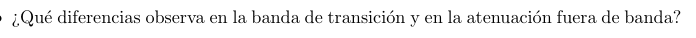

La ventana Rectangular presenta la banda de transición más estrecha debido a que tiene el lóbulo principal más angosto. Las ventanas Triangular, Hanning y Hamming presentan bandas de transición más anchas, siendo Hanning la que presenta la más ancha. Esto se debe a que las funciones de ventana suavizadas ensanchan el lóbulo principal en el dominio de la frecuencia. En cuanto a la atenuación fuera de banda, la ventana Rectangular tiene la menor atenuación para el primer lóbulo lateral, mientras que las ventanas Hanning y Hamming logran una atenuación mayor. La ventana Triangular se encuentra en un punto intermedio. Esta diferencia se debe a que las ventanas con transiciones suaves en el dominio del tiempo producen lóbulos laterales más pequeños en el dominio de la frecuencia, resultando en mayor atenuación de las frecuencias no deseadas. En los gráficos de comparación se puede observar claramente cómo las curvas de Hanning y Hamming caen más abruptamente después de la frecuencia de corte, indicando mayor rechazo fuera de banda.

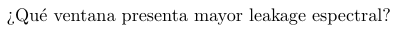

La ventana Rectangular presenta el mayor leakage espectral debido a sus discontinuidades abruptas en los bordes. Cuando aplicamos una ventana rectangular a la respuesta al impulso ideal, la señal se trunca de manera abrupta generando en el dominio de la frecuencia componentes espectrales que se dispersan hacia los lóbulos laterales. Esto causa que la energía se disperse hacia frecuencias que deberían estar atenuadas. Las ventanas Hanning y Hamming reducen significativamente el leakage espectral al tener transiciones más suaves en los bordes, lo que equivale a una especie de suavizado que evita las discontinuidades abruptas. En los espectros de la señal filtrada se puede observar que la ventana Rectangular presenta componentes laterales mucho más pronunciados que las demás ventanas. La ventana Triangular está entre el leakage de la rectangular y la eficiencia de las ventanas tipo coseno.

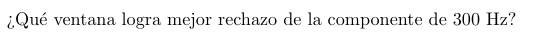

La componente de 300 Hz está ubicada en la banda de rechazo del filtro diseñado con frecuencia de corte de 100 Hz, por lo que todas las ventanas la atenúan significativamente. Sin embargo, la ventana Hanning y la Hamming logran el mejor rechazo. En el espectro de la señal filtrada se puede observar que las componentes en torno a 300 Hz están prácticamente eliminadas en todas las ventanas, pero las curvas de Hanning y Hamming muestran los valores más bajos en esa región. La diferencia práctica entre las ventanas es mínima porque 300 Hz está muy lejos de la frecuencia de corte, lo que asegura que todas operen en la región de alta atenuación.

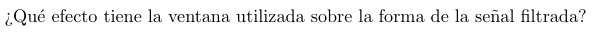

El efecto de la ventana sobre la forma de la señal filtrada se manifiesta principalmente a través de dos fenómenos: el efecto Gibbs y el ripple en la banda de paso. La ventana Rectangular, al no suavizar las transiciones en el dominio de la frecuencia, tiende a producir más oscilaciones (ripple) cerca de las discontinuidades de la respuesta en frecuencia, un fenómeno conocido como efecto Gibbs. Esto se observa en el dominio temporal donde la señal filtrada con ventana rectangular puede presentar oscilaciones más pronunciadas cerca de las transiciones.

Las ventanas con transiciones más suaves (Hanning, Hamming) producen una señal filtrada con menos oscilaciones porque la suavización en el dominio de la frecuencia se traduce en una respuesta temporal más suave. Las curvas de Hanning y Hamming muestran formas más suavizadas en comparación con la curva de la ventana Rectangular. Sin embargo, las transiciones entre la banda de paso y la banda de rechazo es menos abrupta.